<a href="https://colab.research.google.com/github/be-ayush/ai-ml-learning/blob/main/HOML/HOML3_Chapter5_Decision_Trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[['petal length (cm)', 'petal width (cm)']].values
y_iris = iris.target

tree_classifier = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_classifier.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [3]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_classifier,
    out_file='iris_tree.dot',
    feature_names = ['petal length (cm)', 'petal width (cm)'],
    class_names = iris.target_names,
    rounded = True,
    filled = True
)

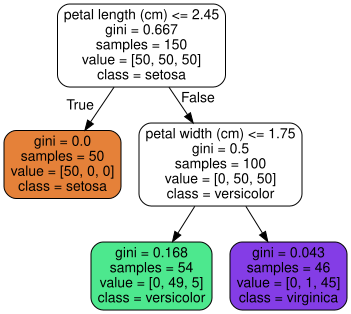

In [4]:
from graphviz import Source

Source.from_file('iris_tree.dot')

In [5]:
tree_classifier.predict_proba([[5, 1.5]]).round(3)

array([[0.   , 0.907, 0.093]])

In [6]:
tree_classifier.predict([[5, 1.5]])

array([1])

In [7]:
## With PCA

from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pipe = make_pipeline(StandardScaler(), PCA())
X_iris_rotated = pipe.fit_transform(X_iris)
tree_classifier_pca = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_classifier_pca.fit(X_iris_rotated, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [8]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(
    n_samples=150,
    noise=0.2,
    random_state=42
)

tree_classifier = DecisionTreeClassifier(random_state=42)
tree_classifier_min_leaf_samples = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

tree_classifier.fit(X_moons, y_moons)
tree_classifier_min_leaf_samples.fit(X_moons, y_moons)

X_moons_test, y_moons_test = make_moons(n_samples=1000, noise=0.2, random_state=45)

print(tree_classifier.score(X_moons_test, y_moons_test))
print(tree_classifier_min_leaf_samples.score(X_moons_test, y_moons_test))

0.906
0.923


In [9]:
## With PCA

from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pca_pipeline = make_pipeline(StandardScaler(), PCA())
X_iris_rotated = pca_pipeline.fit_transform(X_iris)
tree_classifier_pca = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_classifier_pca.fit(X_iris_rotated, y_iris)
tree_classifier.score(X_iris_rotated, y_iris)

0.6266666666666667

In [22]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
import pandas as pd

X_moons, y_moons = make_moons(
    n_samples=10000,
    noise=0.4,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X_moons, y_moons, test_size=0.25, random_state=42)

pipe = Pipeline(steps=[
    ('classifier', DecisionTreeClassifier(random_state=42))
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    "classifier__max_depth": [2, 3, 5, 6, 7],
    "classifier__max_leaf_nodes": list(range(2, 200)),
}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train,y_train)

print("Best params:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)


results = pd.DataFrame(grid_search.cv_results_)
print(results[["mean_test_score", "param_classifier__max_leaf_nodes", "param_classifier__max_depth"]]
      .sort_values("mean_test_score", ascending=False)
      .head(10))

Best params: {'classifier__max_depth': 7, 'classifier__max_leaf_nodes': 27}
Best CV accuracy: 0.856
     mean_test_score  param_classifier__max_leaf_nodes  \
817         0.856000                                27   
818         0.855733                                28   
819         0.855600                                29   
614         0.855467                                22   
814         0.855467                                24   
815         0.855467                                25   
816         0.855467                                26   
615         0.855200                                23   
813         0.854800                                23   
822         0.854667                                32   

     param_classifier__max_depth  
817                            7  
818                            7  
819                            7  
614                            6  
814                            7  
815                            7  
816             

In [23]:
from sklearn.model_selection import ShuffleSplit

n_trees = 1000
n_instances = 100

mini_sets = []

rs = ShuffleSplit(
    n_splits=n_trees,
    test_size=len(X_train) - n_instances,
    random_state = 42
)

for mini_train_index, mini_test_index in rs.split(X_train):
  X_mini_train = X_train[mini_train_index]
  y_mini_train = y_train[mini_train_index]
  mini_sets.append((X_mini_train, y_mini_train))

In [24]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score
import numpy as np

forest = [clone(grid_search.best_estimator_) for _ in range(n_trees)]

accuracy_scores = []

for tree, (X_train_mini_set, y_train_mini_set) in zip(forest, mini_sets):
  tree.fit(X_train_mini_set, y_train_mini_set)

  y_pred = tree.predict(X_test)
  accuracy_scores.append(accuracy_score(y_test, y_pred))

np.mean(accuracy_scores)

np.float64(0.7961467999999999)

In [25]:
Y_pred = np.empty([n_trees, len(X_test)], dtype=np.uint8)

for tree_index, tree in enumerate(forest):
  Y_pred[tree_index] = tree.predict(X_test)

from scipy.stats import mode

y_pred_majority_votes, n_votes = mode(Y_pred, axis=0)

accuracy_score(y_test, y_pred_majority_votes.reshape([-1]))

0.8664